# Trace Efficiency Analysis Visualization

Analyze and visualize the efficiency and correctness metrics from the trace analysis.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [2]:
# Load results
with open('analysis_results/trace_analysis_results.json', 'r') as f:
    results = json.load(f)

summary_df = pd.read_csv('analysis_results/trace_analysis_summary.csv')
agent_df = pd.read_csv('analysis_results/agent_tool_usage.csv')

## Summary Statistics

In [3]:
# Print summary
summary = results['summary']
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"Total traces analyzed: {summary.get('total_traces', 'N/A')}")
print(f"Average total steps: {summary.get('avg_total_steps', 0):.1f}")
print(f"Average core answer step: {summary.get('avg_core_answer_step', 0):.1f}")
print(f"Average potential savings: {summary.get('avg_potential_savings', 0):.1f} steps ({summary.get('avg_savings_percentage', 0):.1f}%)")
print(f"Video match rate: {summary.get('video_match_rate', 0)*100:.1f}%")
print("=" * 60)

ANALYSIS SUMMARY
Total traces analyzed: 70
Average total steps: 82.9
Average core answer step: 5.3
Average potential savings: 77.6 steps (93.0%)
Video match rate: 100.0%


## Efficiency Analysis

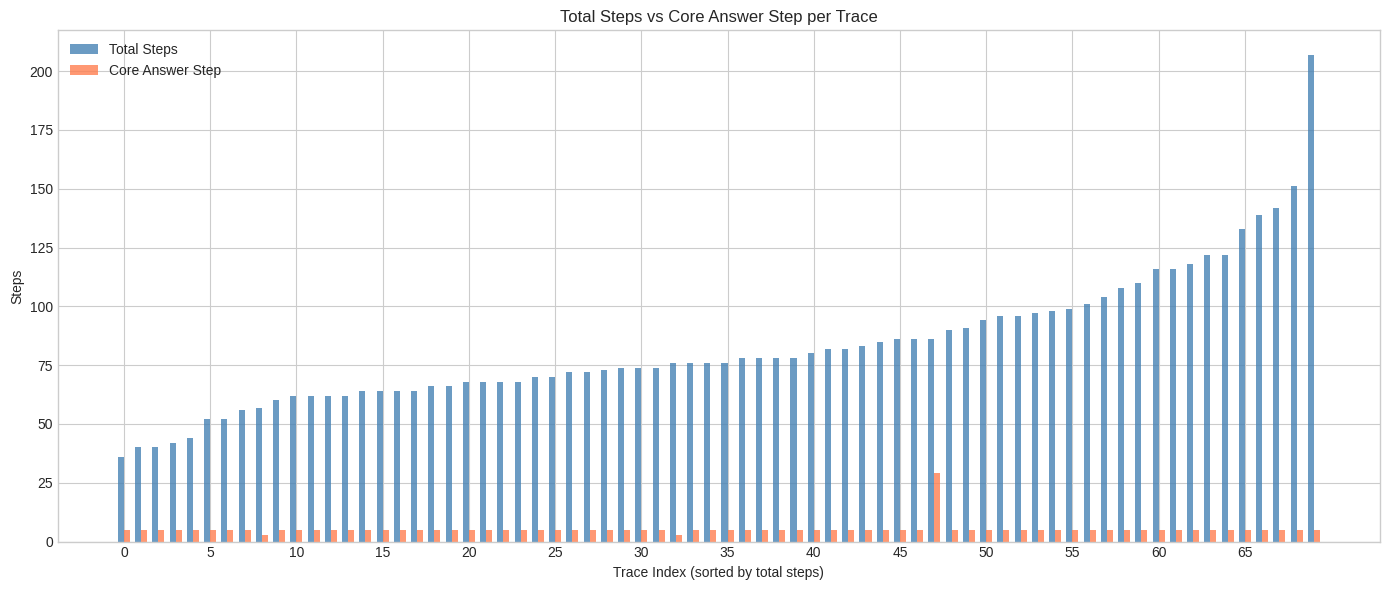

In [4]:
# Plot: Total Steps vs Core Answer Step
fig, ax = plt.subplots(figsize=(14, 6))

# Sort by total steps
df = summary_df.sort_values('total_steps')

x = range(len(df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df['total_steps'], width, label='Total Steps', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], df['core_answer_step'], width, label='Core Answer Step', color='coral', alpha=0.8)

ax.set_xlabel('Trace Index (sorted by total steps)')
ax.set_ylabel('Steps')
ax.set_title('Total Steps vs Core Answer Step per Trace')
ax.legend()
ax.set_xticks(x[::5])
ax.set_xticklabels([f"{i}" for i in range(0, len(df), 5)])

plt.tight_layout()
plt.show()

/tmp/ipykernel_855369/227223629.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([summary_df['potential_savings'], summary_df['savings_pct']], labels=['Potential Savings (steps)', 'Savings (%)'])


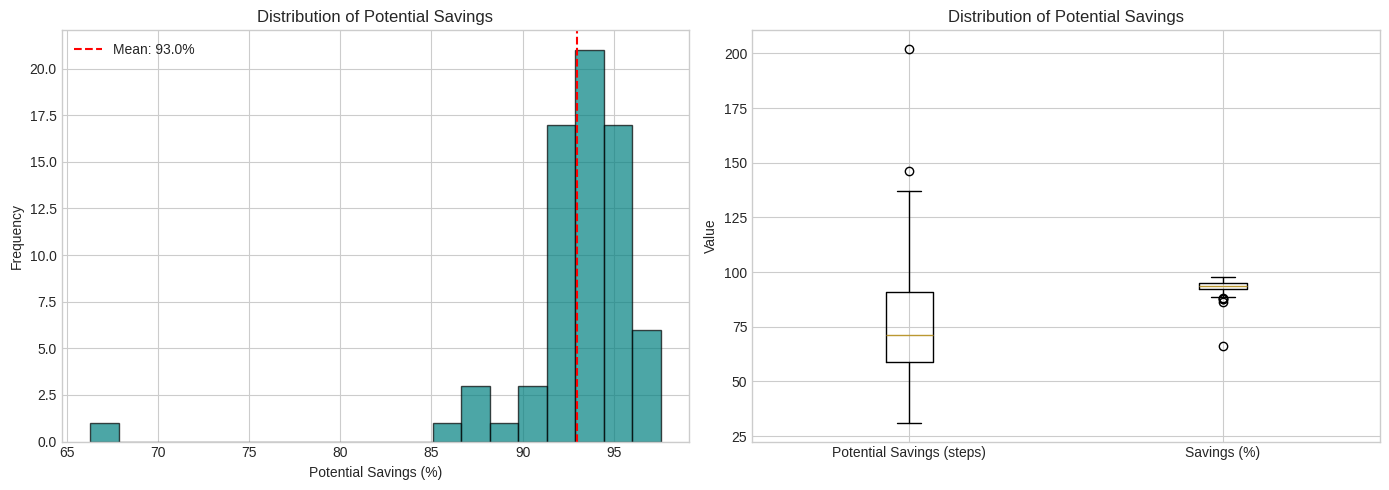

In [5]:
# Plot: Potential Savings Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(summary_df['savings_pct'], bins=20, color='teal', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Potential Savings (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Potential Savings')
axes[0].axvline(summary_df['savings_pct'].mean(), color='red', linestyle='--', label=f"Mean: {summary_df['savings_pct'].mean():.1f}%")
axes[0].legend()

# Box plot
axes[1].boxplot([summary_df['potential_savings'], summary_df['savings_pct']], labels=['Potential Savings (steps)', 'Savings (%)'])
axes[1].set_ylabel('Value')
axes[1].set_title('Distribution of Potential Savings')

plt.tight_layout()
plt.show()

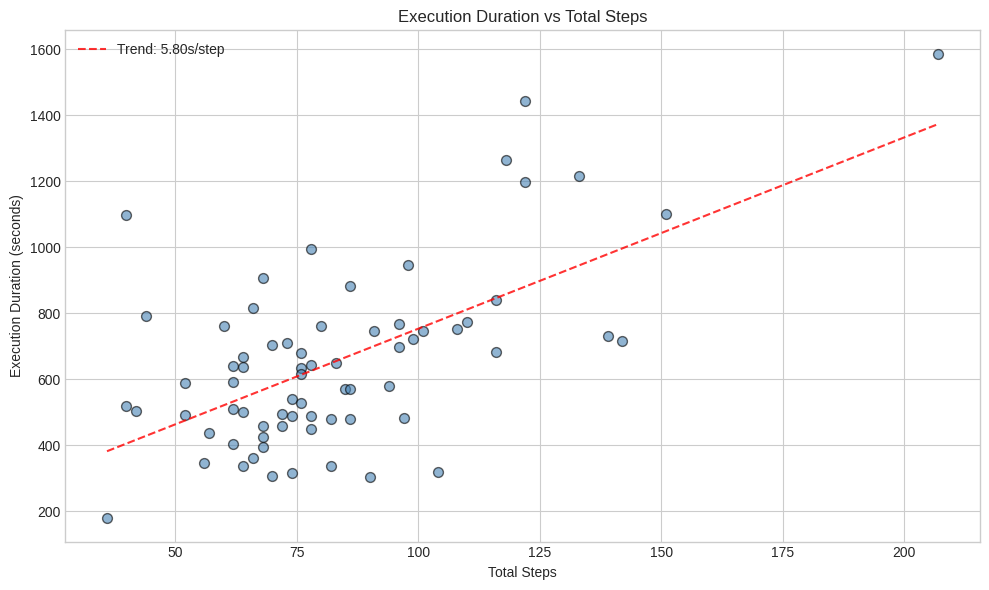

In [7]:
import numpy as np
# Plot: Execution Duration vs Total Steps
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(summary_df['total_steps'], summary_df['execution_duration_ms'] / 1000, 
           alpha=0.6, s=50, c='steelblue', edgecolors='black')

ax.set_xlabel('Total Steps')
ax.set_ylabel('Execution Duration (seconds)')
ax.set_title('Execution Duration vs Total Steps')

# Add trend line
z = np.polyfit(summary_df['total_steps'], summary_df['execution_duration_ms'] / 1000, 1)
p = np.poly1d(z)
x_line = np.linspace(summary_df['total_steps'].min(), summary_df['total_steps'].max(), 100)
ax.plot(x_line, p(x_line), "r--", alpha=0.8, label=f'Trend: {z[0]:.2f}s/step')
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from scipy import stats

# Correlation analysis
correlation = summary_df['total_steps'].corr(summary_df['execution_duration_ms'])
print(f"Correlation between total steps and execution duration: {correlation:.3f}")

Correlation between total steps and execution duration: 0.615


## Agent Tool Usage Analysis

In [9]:
# Plot: Tool usage per agent type
agent_summary = agent_df.groupby('agent_name').agg({
    'tool_calls': ['mean', 'std', 'min', 'max'],
    'llm_calls': ['mean', 'std', 'min', 'max'],
    'trace_id': 'count'
}).round(2)

agent_summary.columns = ['avg_tool_calls', 'std_tool_calls', 'min_tool_calls', 'max_tool_calls',
                          'avg_llm_calls', 'std_llm_calls', 'min_llm_calls', 'max_llm_calls',
                          'count']
agent_summary = agent_summary.reset_index()

print("Tool Usage by Agent Type:")
print(agent_summary.to_string(index=False))

Tool Usage by Agent Type:
                              agent_name  avg_tool_calls  std_tool_calls  min_tool_calls  max_tool_calls  avg_llm_calls  std_llm_calls  min_llm_calls  max_llm_calls  count
                            Orchestrator            4.59            0.92               3               8           5.61           0.91              5              9     70
                          Planning_Agent            1.00             NaN               1               1           3.00            NaN              3              3      1
                         VideoDeepSearch            1.97            0.17               1               2           2.97           0.17              2              3     70
                asr_and_kg_search_worker           10.00             NaN              10              10          11.00            NaN             11             11      1
        asr_and_visual_extraction_worker           16.00             NaN              16              16          

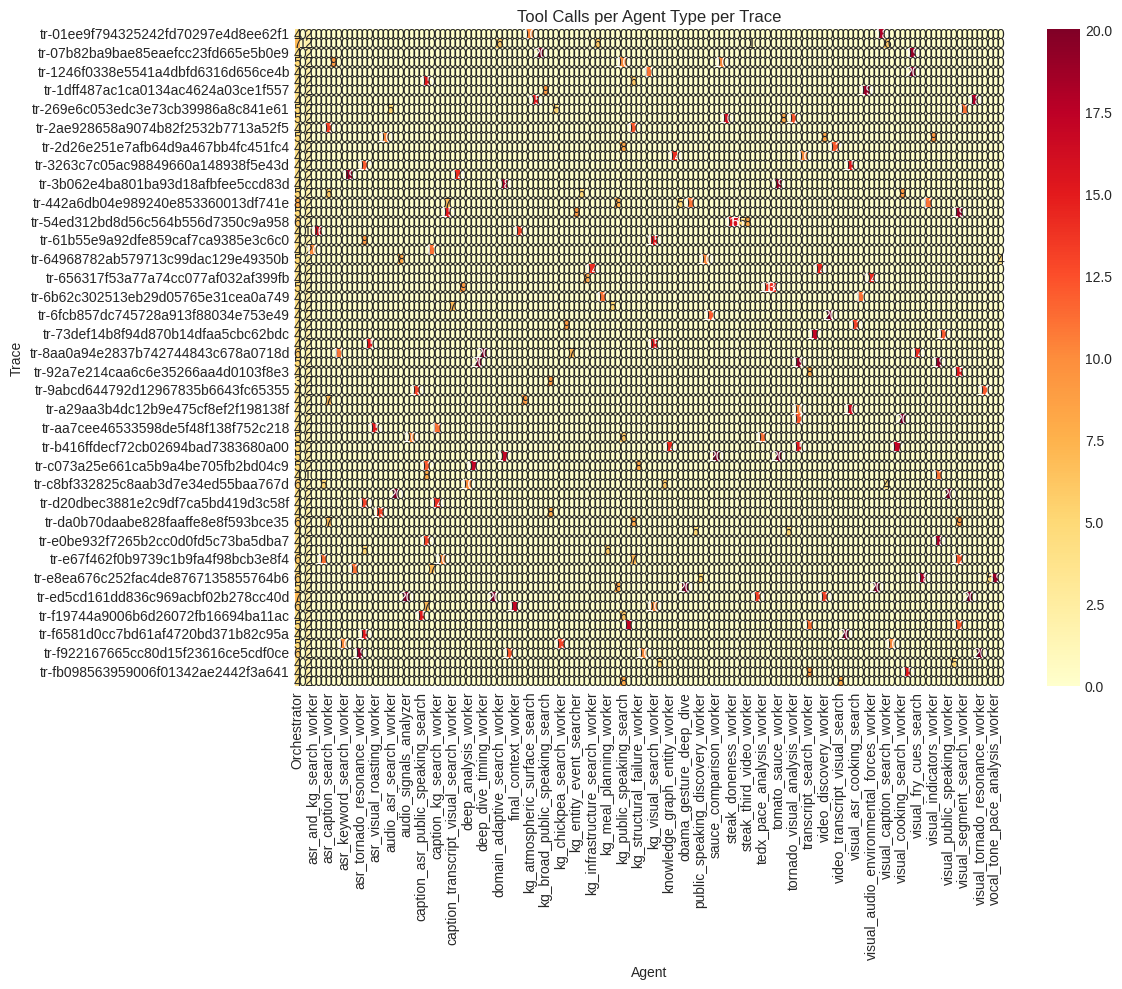

In [10]:
# Plot: Heatmap of tool usage
pivot_df = agent_df.pivot_table(index='trace_id', columns='agent_name', values='tool_calls', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Tool Calls per Agent Type per Trace')
ax.set_xlabel('Agent')
ax.set_ylabel('Trace')

plt.tight_layout()
plt.show()

## Correctness Analysis

In [11]:
# Video match rate
valid_traces = summary_df[summary_df['has_expected_record'] == True]
video_matches = valid_traces['video_match'].sum()
total_with_record = len(valid_traces)

print(f"Traces with expected record: {total_with_record}")
print(f"Video matches: {video_matches}")
print(f"Video match rate: {video_matches/total_with_record*100:.1f}%" if total_with_record > 0 else "No data")

Traces with expected record: 70
Video matches: 70
Video match rate: 100.0%


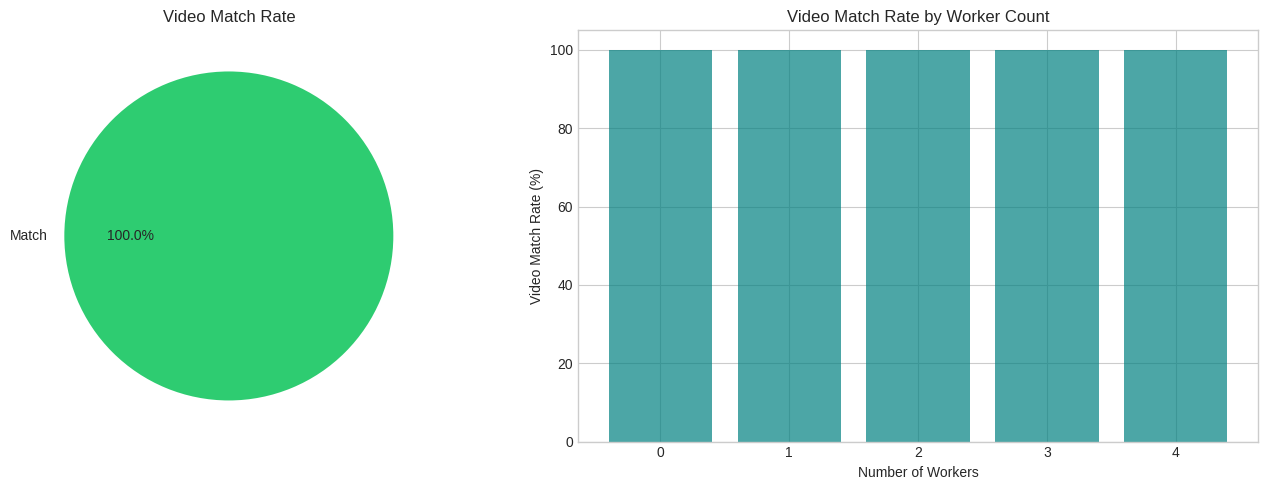

In [12]:
# Plot: Video match rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
match_counts = summary_df['video_match'].value_counts()
labels = ['Match' if x else 'No Match' for x in match_counts.index]
axes[0].pie(match_counts.values, labels=labels, autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Video Match Rate')

# Bar chart by workers
workers_match = summary_df.groupby('workers_count')['video_match'].mean() * 100
axes[1].bar(workers_match.index, workers_match.values, color='teal', alpha=0.7)
axes[1].set_xlabel('Number of Workers')
axes[1].set_ylabel('Video Match Rate (%)')
axes[1].set_title('Video Match Rate by Worker Count')

plt.tight_layout()
plt.show()

## Efficiency vs Correctness Trade-off

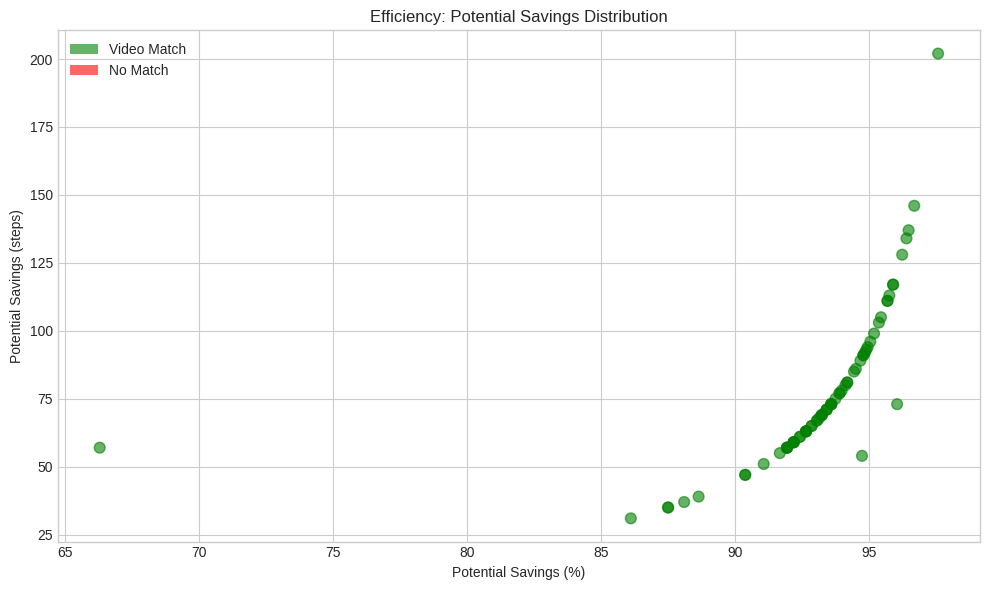

In [13]:
# Plot: Savings vs Video Match
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if x else 'red' for x in summary_df['video_match'].fillna(False)]
ax.scatter(summary_df['savings_pct'], summary_df['potential_savings'], 
           c=colors, alpha=0.6, s=60)

ax.set_xlabel('Potential Savings (%)')
ax.set_ylabel('Potential Savings (steps)')
ax.set_title('Efficiency: Potential Savings Distribution')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.6, label='Video Match'),
                    Patch(facecolor='red', alpha=0.6, label='No Match')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## Key Insights

In [14]:
# Calculate key insights
print("=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

# Most efficient traces
most_efficient = summary_df.nsmallest(5, 'potential_savings')[['trace_id', 'total_steps', 'potential_savings', 'savings_pct']]
print("\nTop 5 Most Efficient Traces (lowest potential savings):")
print(most_efficient.to_string(index=False))

# Least efficient traces
least_efficient = summary_df.nlargest(5, 'potential_savings')[['trace_id', 'total_steps', 'potential_savings', 'savings_pct']]
print("\nTop 5 Least Efficient Traces (highest potential savings):")
print(least_efficient.to_string(index=False))

# Correlation between workers and savings
workers_savings_corr = summary_df['workers_count'].corr(summary_df['savings_pct'])
print(f"\nCorrelation between workers count and savings %: {workers_savings_corr:.3f}")

KEY INSIGHTS

Top 5 Most Efficient Traces (lowest potential savings):
                           trace_id  total_steps  potential_savings  savings_pct
tr-956f710235a40ba3e1de448e3f733f4b           36                 31        86.11
tr-df52bcd29ec748db08e4a30bd83ef818           40                 35        87.50
tr-faafa8257b2d8421ab3e975b4889c6b0           40                 35        87.50
tr-e0e8fdeb6cf39701772b94f461d61ca9           42                 37        88.10
tr-6ee63845088e8d3223735ad2ee908fcc           44                 39        88.64

Top 5 Least Efficient Traces (highest potential savings):
                           trace_id  total_steps  potential_savings  savings_pct
tr-ed5cd161dd836c969acbf02b278cc40d          207                202        97.58
tr-f922167665cc80d15f23616ce5cdf0ce          151                146        96.69
tr-8fafb04c98bd4e967d79ff101ace7c43          142                137        96.48
tr-b891f9cc7bf06f2baddbd235ab3ab41a          139             

In [15]:
# Export summary stats
summary_stats = {
    'total_traces': int(summary['total_traces']),
    'avg_total_steps': float(summary['avg_total_steps']),
    'avg_core_answer_step': float(summary['avg_core_answer_step']),
    'avg_potential_savings': float(summary['avg_potential_savings']),
    'avg_savings_percentage': float(summary['avg_savings_percentage']),
    'video_match_rate': float(summary['video_match_rate']),
    'min_steps': int(summary['min_steps']),
    'max_steps': int(summary['max_steps'])
}

print("\nSummary Statistics:")
for k, v in summary_stats.items():
    print(f"  {k}: {v}")


Summary Statistics:
  total_traces: 70
  avg_total_steps: 82.88571428571429
  avg_core_answer_step: 5.285714285714286
  avg_potential_savings: 77.6
  avg_savings_percentage: 92.98628571428571
  video_match_rate: 1.0
  min_steps: 36
  max_steps: 207
